# Exploratory Data Analytics of EV Charging Patterns for Intelligent Transportation Systems

 
**Assignment:** Assignment 1 - Exploratory Data Analytics  
**Theme 3:** Intelligent Transportation System

## 1. Import Libraries

The notebook uses Pandas, NumPy, Matplotlib, and Seaborn for EDA. SciPy is used for hypothesis testing. If SciPy is missing, install it in Jupyter using `!pip install scipy`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style='whitegrid')
except ImportError:
    sns = None
    print('Seaborn is not installed. Some charts will use basic Matplotlib/Pandas style.')

try:
    from scipy import stats
except ImportError:
    stats = None
    print('SciPy is not installed. Run: !pip install scipy')

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
plt.rcParams['figure.figsize'] = (10, 6)


## 2. Load Dataset


In [2]:
df = pd.read_csv('ev_charging_dataset.csv')

print('Dataset shape:', df.shape)
df.head()


Dataset shape: (8354, 27)


,timestamp,station_id,location_type,vehicle_id,vehicle_type,arrival_time,charging_start_time,charging_end_time,waiting_time,battery_capacity_kWh,initial_soc,final_soc,energy_consumed_kWh,charging_power_kW,charging_duration,queue_length,station_load,electricity_price,renewable_energy_ratio,traffic_density,weather_condition,day_of_week,time_slot,charging_demand,assigned_charger_id,charging_priority,optimization_reward
0,2025-01-01 00:00:00,ST004,Urban,EV10000,Two-Wheeler,2025-01-01 00:00:00,2025-01-01 00:12:00,2025-01-01 04:33:00,12,60,48.985,99.866,30.529,7,261.674,4,15.162,13.660,0.280,Low,Cloudy,Wednesday,Off-Peak,17.242,CH4,Low,-8.622
1,2025-01-01 00:15:00,ST005,Urban,EV10001,Two-Wheeler,2025-01-01 00:15:00,2025-01-01 00:23:00,2025-01-01 01:12:00,8,100,58.495,100.000,41.505,50,49.917,3,20.997,5.470,0.392,Low,Rainy,Wednesday,Off-Peak,18.325,CH9,Low,-1.936
2,2025-01-01 00:30:00,ST019,Highway,EV10002,Car,2025-01-01 00:30:00,2025-01-01 00:41:00,2025-01-01 01:35:00,11,75,35.712,95.733,45.016,50,54.020,8,31.606,9.500,0.104,Low,Clear,Wednesday,Off-Peak,36.028,CH2,Low,-18.202
3,2025-01-01 00:45:00,ST008,Urban,EV10003,Two-Wheeler,2025-01-01 00:45:00,2025-01-01 00:54:00,2025-01-01 03:29:00,9,40,29.271,100.000,28.292,11,155.773,3,21.803,6.220,0.249,Low,Clear,Wednesday,Off-Peak,17.147,CH9,Medium,-7.404
4,2025-01-01 01:00:00,ST008,Highway,EV10004,Two-Wheeler,2025-01-01 01:00:00,2025-01-01 01:08:00,2025-01-01 06:14:00,8,75,25.586,100.000,55.811,11,306.369,5,15.626,13.420,0.235,Low,Cloudy,Wednesday,Off-Peak,14.578,CH1,Low,-6.577


## 3. Data Understanding and Initial Quality Check


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8354 entries, 0 to 8353
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   timestamp               8354 non-null   object 
 1   station_id              8354 non-null   object 
 2   location_type           8354 non-null   object 
 3   vehicle_id              8354 non-null   object 
 4   vehicle_type            8354 non-null   object 
 5   arrival_time            8354 non-null   object 
 6   charging_start_time     8354 non-null   object 
 7   charging_end_time       8354 non-null   object 
 8   waiting_time            8354 non-null   int64  
 9   battery_capacity_kWh    8354 non-null   int64  
 10  initial_soc             8354 non-null   float64
 11  final_soc               8354 non-null   float64
 12  energy_consumed_kWh     8354 non-null   float64
 13  charging_power_kW       8354 non-null   int64  
 14  charging_duration       8354 non-null   

In [4]:
# Clean column names by removing leading/trailing spaces.
df.columns = df.columns.str.strip()

missing_summary = df.isna().sum().to_frame('missing_count')
missing_summary['missing_percent'] = (missing_summary['missing_count'] / len(df) * 100).round(2)
missing_summary


,missing_count,missing_percent
timestamp,0,0.000
station_id,0,0.000
location_type,0,0.000
vehicle_id,0,0.000
vehicle_type,0,0.000
arrival_time,0,0.000
charging_start_time,0,0.000
charging_end_time,0,0.000
waiting_time,0,0.000
battery_capacity_kWh,0,0.000


In [5]:
print('Duplicate rows:', df.duplicated().sum())

# Summary statistics for numeric and categorical fields.
df.describe(include='all').T


Duplicate rows: 0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
timestamp,8354,8354,2025-01-01 00:00:00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
station_id,8354,20,ST013,459,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location_type,8354,2,Urban,4188,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vehicle_id,8354,8354,EV10000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vehicle_type,8354,3,Car,2833,NaN,NaN,NaN,NaN,NaN,NaN,NaN
arrival_time,8354,8354,2025-01-01 00:00:00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
charging_start_time,8354,8304,2025-02-12 03:30:00,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
charging_end_time,8354,8109,2025-02-21 06:09:00,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
waiting_time,"8,354.000",NaN,NaN,NaN,9.526,4.894,0.000,6.000,9.000,13.000,28.000
battery_capacity_kWh,"8,354.000",NaN,NaN,NaN,61.080,25.001,30.000,40.000,60.000,75.000,100.000


In [6]:
categorical_cols = [
    'station_id', 'location_type', 'vehicle_type', 'traffic_density',
    'weather_condition', 'day_of_week', 'time_slot', 'charging_priority'
]

for col in categorical_cols:
    print(f'\n{col}')
    print(df[col].value_counts())



station_id
ST013    459
ST001    443
ST005    438
ST017    434
ST011    432
ST003    431
ST019    427
ST012    421
ST009    417
ST015    416
ST006    413
ST014    412
ST020    412
ST018    412
ST010    406
ST004    405
ST008    400
ST002    398
ST007    391
ST016    387
Name: station_id, dtype: int64

location_type
Urban      4188
Highway    4166
Name: location_type, dtype: int64

vehicle_type
Car            2833
Two-Wheeler    2761
Bus            2760
Name: vehicle_type, dtype: int64

traffic_density
Low       3134
High      3132
Medium    2088
Name: traffic_density, dtype: int64

weather_condition
Rainy     2854
Cloudy    2760
Clear     2740
Name: weather_condition, dtype: int64

day_of_week
Wednesday    1248
Thursday     1248
Friday       1248
Saturday     1154
Sunday       1152
Monday       1152
Tuesday      1152
Name: day_of_week, dtype: int64

time_slot
Off-Peak    5222
Peak        3132
Name: time_slot, dtype: int64

charging_priority
Medium    2913
Low       2784
High      2657

## 4. Data Preparation

Convert timestamp columns, create useful time features, and check whether recorded durations are consistent with the datetime fields.


In [7]:
date_cols = ['timestamp', 'arrival_time', 'charging_start_time', 'charging_end_time']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Create additional time-based features for EDA.
df['hour'] = df['timestamp'].dt.hour
df['month'] = df['timestamp'].dt.month
df['date'] = df['timestamp'].dt.date
df['is_weekend'] = df['day_of_week'].isin(['Saturday', 'Sunday'])

# Recalculate durations from timestamps for validation.
df['calculated_waiting_time'] = (df['charging_start_time'] - df['arrival_time']).dt.total_seconds() / 60
df['calculated_charging_duration'] = (df['charging_end_time'] - df['charging_start_time']).dt.total_seconds() / 60

validation = pd.DataFrame({
    'waiting_time_difference_mean': [(df['waiting_time'] - df['calculated_waiting_time']).abs().mean()],
    'charging_duration_difference_mean': [(df['charging_duration'] - df['calculated_charging_duration']).abs().mean()]
})
validation


,waiting_time_difference_mean,charging_duration_difference_mean
0,0.000,0.501


In [8]:
# Drop rows only if critical fields are missing. The original dataset has no missing values,
# but this step is included for reproducibility and assessment clarity.
key_cols = [
    'timestamp', 'station_id', 'location_type', 'vehicle_type', 'arrival_time',
    'charging_start_time', 'charging_end_time', 'waiting_time', 'charging_duration',
    'energy_consumed_kWh', 'queue_length', 'station_load', 'traffic_density',
    'weather_condition', 'time_slot', 'charging_demand'
]

df_cleaned = df.dropna(subset=key_cols).copy()
print('Rows before cleaning:', len(df))
print('Rows after cleaning:', len(df_cleaned))


Rows before cleaning: 8354
Rows after cleaning: 8354


## 5. Optional Station Location Conflict Check

This checks whether the same `station_id` appears under more than one `location_type`. If conflicts exist, report them as a data quality issue. For the main analysis, we continue with the original records because a station may be simulated or reused across contexts in the dataset.


In [9]:
location_conflicts = df_cleaned.groupby('station_id')['location_type'].nunique()
conflicting_stations = location_conflicts[location_conflicts > 1]

print('Stations with more than one location_type:', len(conflicting_stations))
conflicting_stations.head(10)


Stations with more than one location_type: 20


station_id
ST001    2
ST002    2
ST003    2
ST004    2
ST005    2
ST006    2
ST007    2
ST008    2
ST009    2
ST010    2
Name: location_type, dtype: int64

## 6. Exploratory Data Analysis


In [10]:
numeric_cols = [
    'waiting_time', 'battery_capacity_kWh', 'initial_soc', 'final_soc',
    'energy_consumed_kWh', 'charging_power_kW', 'charging_duration',
    'queue_length', 'station_load', 'electricity_price',
    'renewable_energy_ratio', 'charging_demand', 'optimization_reward'
]

df_cleaned[numeric_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
waiting_time,"8,354.000",9.526,4.894,0.000,6.000,9.000,13.000,28.000
battery_capacity_kWh,"8,354.000",61.080,25.001,30.000,40.000,60.000,75.000,100.000
initial_soc,"8,354.000",34.808,14.479,10.001,22.372,34.639,47.311,59.992
final_soc,"8,354.000",98.496,3.258,65.080,98.464,99.998,100.000,100.000
energy_consumed_kWh,"8,354.000",39.080,18.974,7.502,23.675,35.148,51.363,89.929
charging_power_kW,"8,354.000",22.449,16.813,7.000,11.000,11.000,22.000,50.000
charging_duration,"8,354.000",178.700,149.121,10.000,64.118,133.700,247.946,776.551
queue_length,"8,354.000",4.592,2.829,0.000,3.000,5.000,7.000,15.000
station_load,"8,354.000",53.177,27.381,10.053,28.030,49.421,77.600,100.000
electricity_price,"8,354.000",9.960,2.879,5.000,7.510,9.955,12.398,15.000


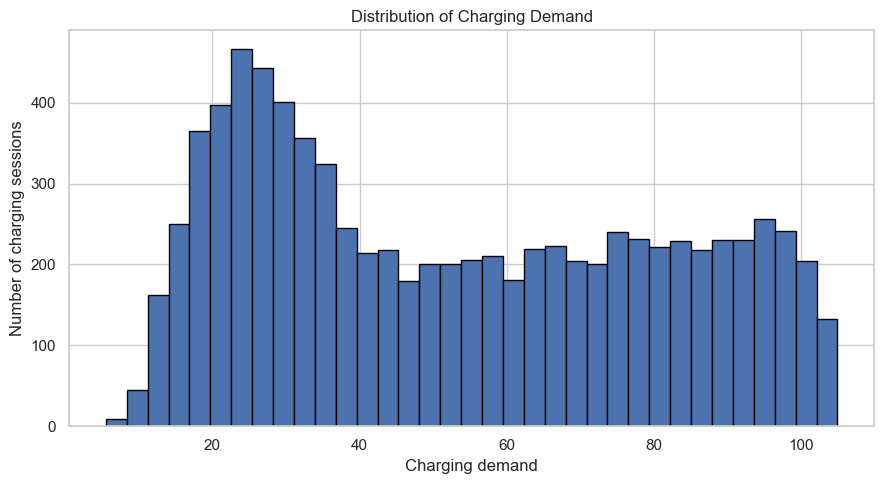

In [11]:
# Distribution of charging demand
plt.figure(figsize=(9, 5))
plt.hist(df_cleaned['charging_demand'], bins=35, edgecolor='black')
plt.title('Distribution of Charging Demand')
plt.xlabel('Charging demand')
plt.ylabel('Number of charging sessions')
plt.tight_layout()
plt.show()


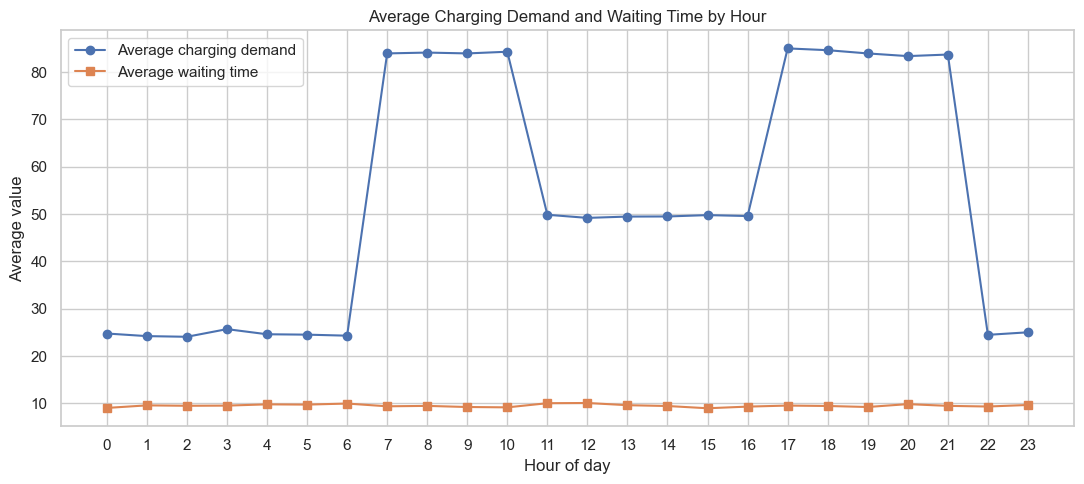

,hour,average_charging_demand,average_waiting_time,session_count
0,0,24.769,9.049,350
1,1,24.218,9.589,348
2,2,24.077,9.503,348
3,3,25.693,9.537,348
4,4,24.611,9.805,348
5,5,24.527,9.753,348
6,6,24.311,9.974,348
7,7,83.931,9.394,348
8,8,84.108,9.480,348
9,9,83.930,9.244,348


In [12]:
# Average charging demand and waiting time by hour
hourly = df_cleaned.groupby('hour', as_index=False).agg(
    average_charging_demand=('charging_demand', 'mean'),
    average_waiting_time=('waiting_time', 'mean'),
    session_count=('vehicle_id', 'count')
)

plt.figure(figsize=(11, 5))
plt.plot(hourly['hour'], hourly['average_charging_demand'], marker='o', label='Average charging demand')
plt.plot(hourly['hour'], hourly['average_waiting_time'], marker='s', label='Average waiting time')
plt.title('Average Charging Demand and Waiting Time by Hour')
plt.xlabel('Hour of day')
plt.ylabel('Average value')
plt.xticks(range(0, 24))
plt.legend()
plt.tight_layout()
plt.show()

hourly


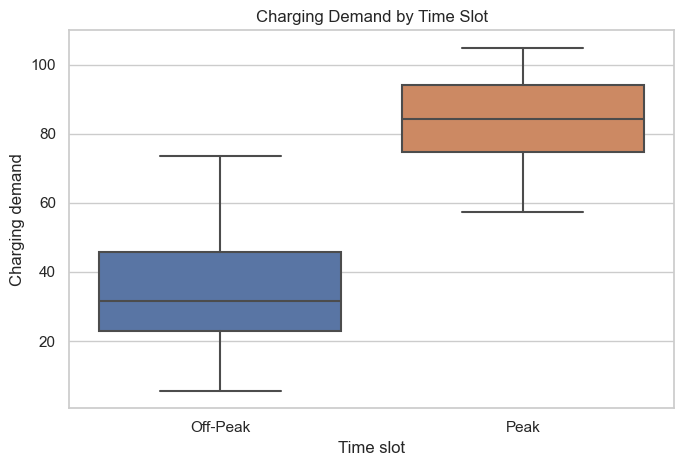

In [13]:
# Charging demand by peak/off-peak period
plt.figure(figsize=(7, 5))
if sns:
    sns.boxplot(data=df_cleaned, x='time_slot', y='charging_demand')
else:
    df_cleaned.boxplot(column='charging_demand', by='time_slot')
plt.title('Charging Demand by Time Slot')
plt.xlabel('Time slot')
plt.ylabel('Charging demand')
plt.suptitle('')
plt.tight_layout()
plt.show()


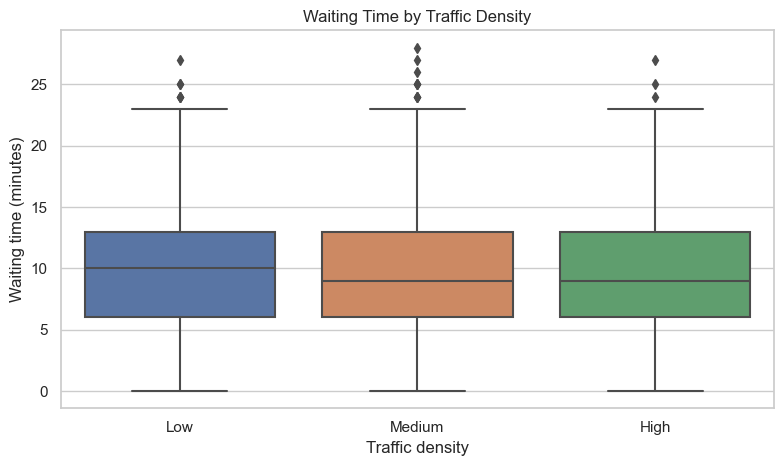

In [14]:
# Waiting time by traffic density
plt.figure(figsize=(8, 5))
traffic_order = ['Low', 'Medium', 'High']
if sns:
    sns.boxplot(data=df_cleaned, x='traffic_density', y='waiting_time', order=traffic_order)
else:
    df_cleaned.boxplot(column='waiting_time', by='traffic_density')
plt.title('Waiting Time by Traffic Density')
plt.xlabel('Traffic density')
plt.ylabel('Waiting time (minutes)')
plt.suptitle('')
plt.tight_layout()
plt.show()


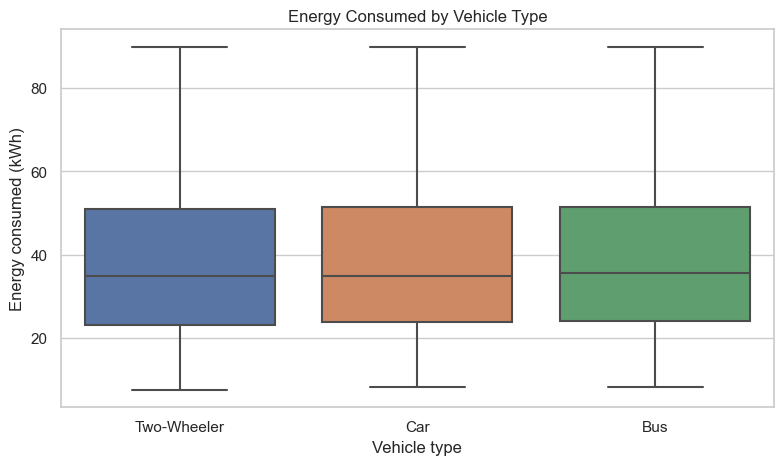

In [15]:
# Energy consumption by vehicle type
plt.figure(figsize=(8, 5))
if sns:
    sns.boxplot(data=df_cleaned, x='vehicle_type', y='energy_consumed_kWh')
else:
    df_cleaned.boxplot(column='energy_consumed_kWh', by='vehicle_type')
plt.title('Energy Consumed by Vehicle Type')
plt.xlabel('Vehicle type')
plt.ylabel('Energy consumed (kWh)')
plt.suptitle('')
plt.tight_layout()
plt.show()


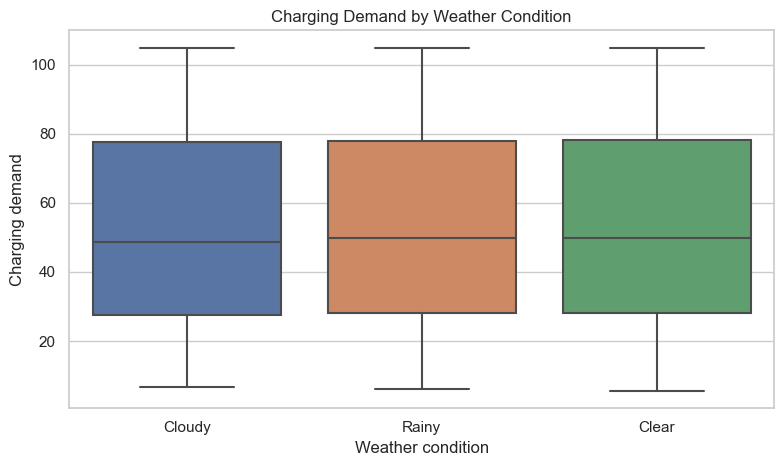

In [16]:
# Charging demand by weather condition
plt.figure(figsize=(8, 5))
if sns:
    sns.boxplot(data=df_cleaned, x='weather_condition', y='charging_demand')
else:
    df_cleaned.boxplot(column='charging_demand', by='weather_condition')
plt.title('Charging Demand by Weather Condition')
plt.xlabel('Weather condition')
plt.ylabel('Charging demand')
plt.suptitle('')
plt.tight_layout()
plt.show()


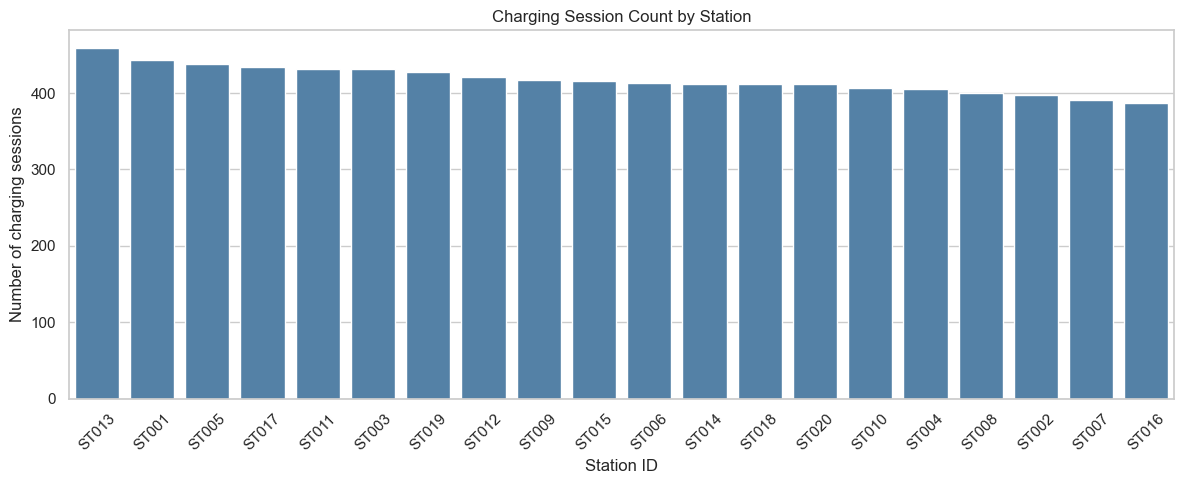

,station_id,session_count,average_waiting_time,average_charging_duration,average_energy_consumed,average_station_load,average_charging_demand
12,ST013,459,9.471,183.484,40.659,53.602,53.411
0,ST001,443,9.492,173.774,39.782,54.509,54.247
4,ST005,438,9.297,186.341,41.024,52.923,52.944
16,ST017,434,9.509,181.838,39.436,52.057,52.030
10,ST011,432,9.769,167.866,38.127,51.137,51.094
2,ST003,431,9.640,177.710,37.570,54.921,55.135
18,ST019,427,9.576,171.044,38.436,51.601,51.540
11,ST012,421,9.705,186.710,39.573,55.853,56.073
8,ST009,417,9.859,177.186,40.638,52.534,52.520
14,ST015,416,9.505,163.106,38.599,53.220,52.937


In [17]:
# Station utilization ranking
station_summary = df_cleaned.groupby('station_id', as_index=False).agg(
    session_count=('vehicle_id', 'count'),
    average_waiting_time=('waiting_time', 'mean'),
    average_charging_duration=('charging_duration', 'mean'),
    average_energy_consumed=('energy_consumed_kWh', 'mean'),
    average_station_load=('station_load', 'mean'),
    average_charging_demand=('charging_demand', 'mean')
).sort_values('session_count', ascending=False)

plt.figure(figsize=(12, 5))
if sns:
    sns.barplot(data=station_summary, x='station_id', y='session_count', color='steelblue')
else:
    plt.bar(station_summary['station_id'], station_summary['session_count'])
plt.title('Charging Session Count by Station')
plt.xlabel('Station ID')
plt.ylabel('Number of charging sessions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

station_summary.head(10)


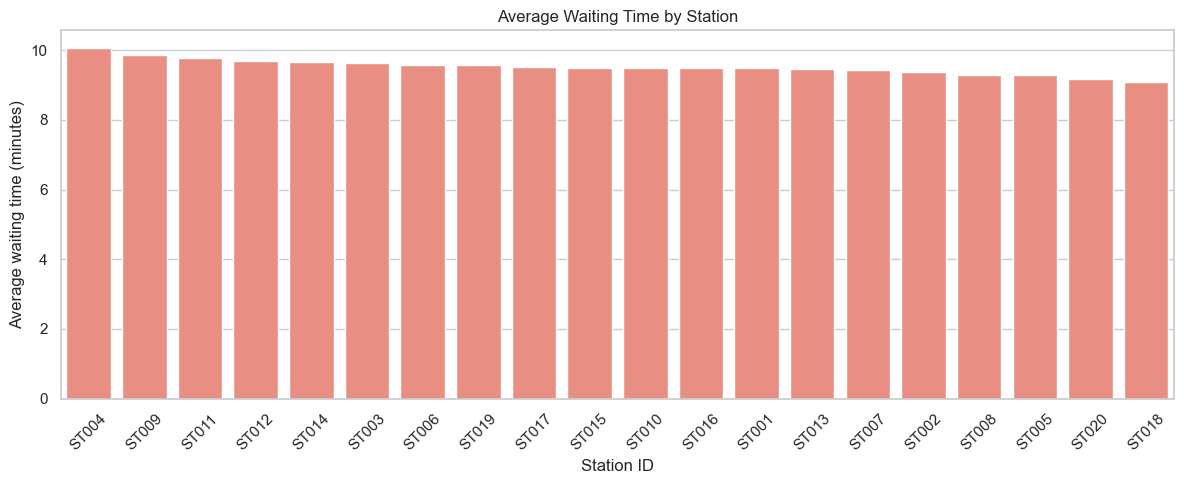

,station_id,session_count,average_waiting_time,average_charging_duration,average_energy_consumed,average_station_load,average_charging_demand
3,ST004,405,10.067,181.672,38.747,54.491,54.496
8,ST009,417,9.859,177.186,40.638,52.534,52.520
10,ST011,432,9.769,167.866,38.127,51.137,51.094
11,ST012,421,9.705,186.710,39.573,55.853,56.073
13,ST014,412,9.663,185.136,38.923,52.778,53.146
2,ST003,431,9.640,177.710,37.570,54.921,55.135
5,ST006,413,9.586,174.852,38.610,52.083,52.081
18,ST019,427,9.576,171.044,38.436,51.601,51.540
16,ST017,434,9.509,181.838,39.436,52.057,52.030
14,ST015,416,9.505,163.106,38.599,53.220,52.937


In [18]:
# Average waiting time by station
waiting_by_station = station_summary.sort_values('average_waiting_time', ascending=False)

plt.figure(figsize=(12, 5))
if sns:
    sns.barplot(data=waiting_by_station, x='station_id', y='average_waiting_time', color='salmon')
else:
    plt.bar(waiting_by_station['station_id'], waiting_by_station['average_waiting_time'])
plt.title('Average Waiting Time by Station')
plt.xlabel('Station ID')
plt.ylabel('Average waiting time (minutes)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

waiting_by_station.head(10)


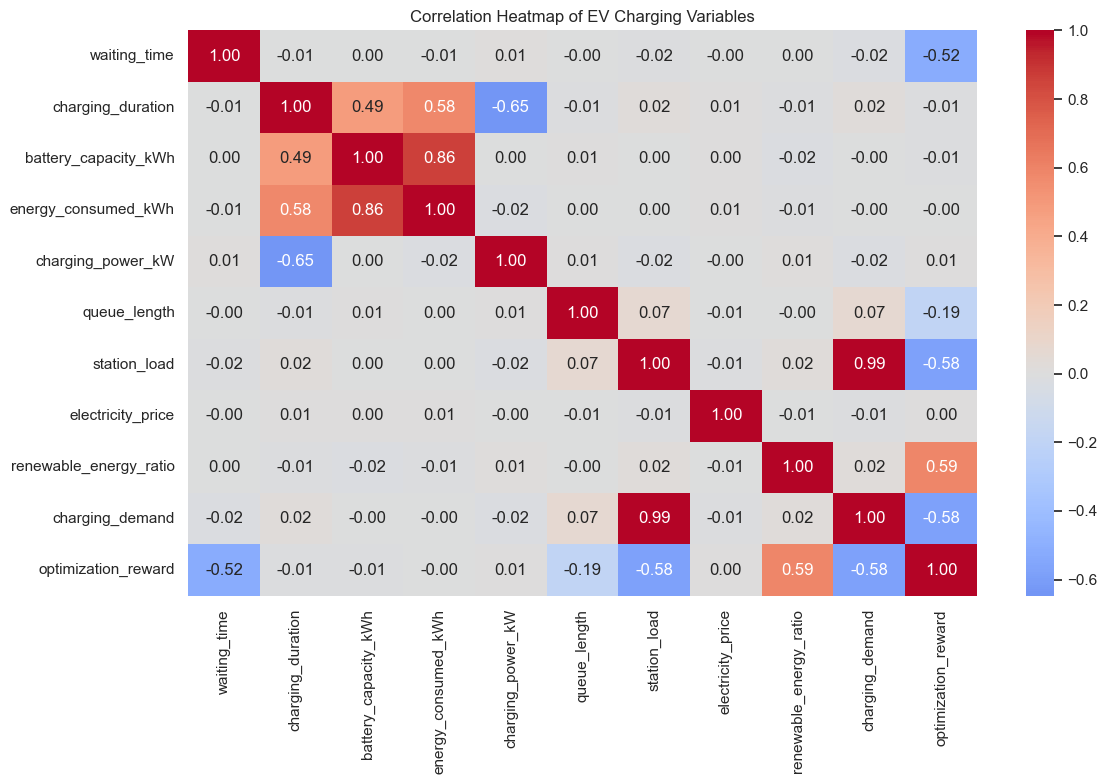

In [19]:
# Correlation heatmap for key numerical variables
correlation_cols = [
    'waiting_time', 'charging_duration', 'battery_capacity_kWh',
    'energy_consumed_kWh', 'charging_power_kW', 'queue_length',
    'station_load', 'electricity_price', 'renewable_energy_ratio',
    'charging_demand', 'optimization_reward'
]

correlation_matrix = df_cleaned[correlation_cols].corr(method='pearson')
plt.figure(figsize=(12, 8))
if sns:
    sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
else:
    plt.imshow(correlation_matrix, cmap='coolwarm')
    plt.colorbar()
    plt.xticks(range(len(correlation_cols)), correlation_cols, rotation=90)
    plt.yticks(range(len(correlation_cols)), correlation_cols)
plt.title('Correlation Heatmap of EV Charging Variables')
plt.tight_layout()
plt.show()


## 7. Outlier / Anomaly Detection

Outliers are checked using the IQR method. They are not automatically deleted because unusually long waiting time or charging duration may be meaningful for ITS congestion analysis.


In [20]:
target_columns = ['optimization_reward', 'charging_duration', 'waiting_time', 'charging_demand']

outlier_summary = []
for col in target_columns:
    q1 = df_cleaned[col].quantile(0.25)
    q3 = df_cleaned[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_count = ((df_cleaned[col] < lower_bound) | (df_cleaned[col] > upper_bound)).sum()
    outlier_summary.append([col, lower_bound, upper_bound, outlier_count])

outlier_summary = pd.DataFrame(outlier_summary, columns=['variable', 'lower_bound', 'upper_bound', 'outlier_count'])
outlier_summary


,variable,lower_bound,upper_bound,outlier_count
0,optimization_reward,-38.226,14.765,7
1,charging_duration,-211.624,523.688,298
2,waiting_time,-4.500,23.500,18
3,charging_demand,-46.989,152.745,0


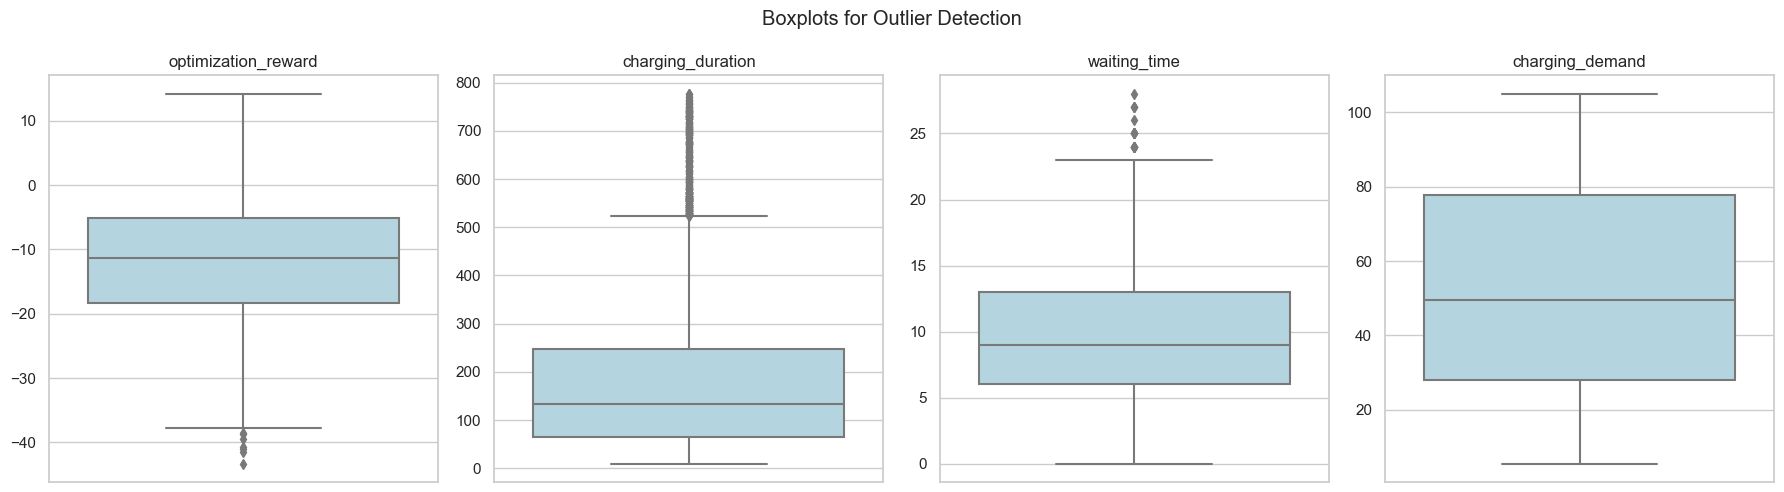

In [21]:
fig, axes = plt.subplots(1, len(target_columns), figsize=(18, 5))
for ax, col in zip(axes, target_columns):
    if sns:
        sns.boxplot(y=df_cleaned[col], ax=ax, color='lightblue')
    else:
        ax.boxplot(df_cleaned[col].dropna())
    ax.set_title(col)
    ax.set_ylabel('')
plt.suptitle('Boxplots for Outlier Detection')
plt.tight_layout()
plt.show()


## 8. Statistical Hypothesis Testing

Use these tests in the report. Interpret p-values using a 0.05 significance level. Also compare group means/medians so the result has practical meaning, not only statistical meaning.


In [22]:
def group_summary(data, group_col, value_col):
    return data.groupby(group_col)[value_col].agg(['count', 'mean', 'median', 'std', 'min', 'max']).round(3)

def explain_p_value(p_value, alpha=0.05):
    if p_value < alpha:
        return f'p = {p_value:.5f}. Reject H0: the difference/relationship is statistically significant.'
    return f'p = {p_value:.5f}. Fail to reject H0: no statistically significant evidence was found.'


### Test 1: Charging Demand During Peak vs Off-Peak Periods

- **H0:** Charging demand is the same during peak and off-peak periods.
- **H1:** Charging demand differs between peak and off-peak periods.


In [23]:
group_summary(df_cleaned, 'time_slot', 'charging_demand')


,count,mean,median,std,min,max
time_slot,,,,,,
Off-Peak,5222,34.601,31.679,14.650,5.506,73.470
Peak,3132,84.093,84.383,11.721,57.369,104.986


In [24]:
peak = df_cleaned.loc[df_cleaned['time_slot'] == 'Peak', 'charging_demand']
off_peak = df_cleaned.loc[df_cleaned['time_slot'] == 'Off-Peak', 'charging_demand']

if stats:
    test_result = stats.mannwhitneyu(peak, off_peak, alternative='two-sided')
    print('Mann-Whitney U statistic:', round(test_result.statistic, 3))
    print(explain_p_value(test_result.pvalue))
else:
    print('Install SciPy to run this test: !pip install scipy')


Mann-Whitney U statistic: 16305898.0
p = 0.00000. Reject H0: the difference/relationship is statistically significant.


### Test 2: Waiting Time Across Traffic Density Levels

- **H0:** Waiting time is the same across low, medium, and high traffic density.
- **H1:** At least one traffic density group has a different waiting time.


In [25]:
group_summary(df_cleaned, 'traffic_density', 'waiting_time')


,count,mean,median,std,min,max
traffic_density,,,,,,
High,3132,9.431,9.000,4.886,0,27
Low,3134,9.581,10.000,4.868,0,27
Medium,2088,9.588,9.000,4.946,0,28


In [26]:
traffic_groups = [group['waiting_time'] for _, group in df_cleaned.groupby('traffic_density')]

if stats:
    test_result = stats.kruskal(*traffic_groups)
    print('Kruskal-Wallis statistic:', round(test_result.statistic, 3))
    print(explain_p_value(test_result.pvalue))
else:
    print('Install SciPy to run this test: !pip install scipy')


Kruskal-Wallis statistic: 1.857
p = 0.39514. Fail to reject H0: no statistically significant evidence was found.


### Test 3: Energy Consumption Across Vehicle Types

- **H0:** Energy consumed is the same across vehicle types.
- **H1:** At least one vehicle type has different energy consumption.


In [27]:
group_summary(df_cleaned, 'vehicle_type', 'energy_consumed_kWh')


,count,mean,median,std,min,max
vehicle_type,,,,,,
Bus,2760,39.446,35.565,18.985,8.333,89.929
Car,2833,39.082,34.951,19.029,8.333,89.831
Two-Wheeler,2761,38.711,34.911,18.905,7.502,89.899


In [28]:
vehicle_groups = [group['energy_consumed_kWh'] for _, group in df_cleaned.groupby('vehicle_type')]

if stats:
    test_result = stats.kruskal(*vehicle_groups)
    print('Kruskal-Wallis statistic:', round(test_result.statistic, 3))
    print(explain_p_value(test_result.pvalue))
else:
    print('Install SciPy to run this test: !pip install scipy')


Kruskal-Wallis statistic: 2.33
p = 0.31187. Fail to reject H0: no statistically significant evidence was found.


### Test 4: Relationship Between Station Load and Charging Demand

- **H0:** Station load is not associated with charging demand.
- **H1:** Station load is associated with charging demand.


In [29]:
if stats:
    rho, p_value = stats.spearmanr(df_cleaned['station_load'], df_cleaned['charging_demand'])
    print('Spearman correlation:', round(rho, 3))
    print(explain_p_value(p_value))
else:
    print('Spearman correlation matrix:')
    print(df_cleaned[['station_load', 'charging_demand']].corr(method='spearman'))


Spearman correlation: 0.992
p = 0.00000. Reject H0: the difference/relationship is statistically significant.


### Test 5: Charging Demand Across Weather Conditions

- **H0:** Charging demand is the same across weather conditions.
- **H1:** At least one weather condition has different charging demand.


In [30]:
group_summary(df_cleaned, 'weather_condition', 'charging_demand')


,count,mean,median,std,min,max
weather_condition,,,,,,
Clear,2740,53.465,49.767,27.657,5.506,104.956
Cloudy,2760,52.809,48.735,27.550,6.810,104.948
Rainy,2854,53.196,49.842,27.492,6.214,104.986


In [31]:
weather_groups = [group['charging_demand'] for _, group in df_cleaned.groupby('weather_condition')]

if stats:
    test_result = stats.kruskal(*weather_groups)
    print('Kruskal-Wallis statistic:', round(test_result.statistic, 3))
    print(explain_p_value(test_result.pvalue))
else:
    print('Install SciPy to run this test: !pip install scipy')


Kruskal-Wallis statistic: 0.869
p = 0.64749. Fail to reject H0: no statistically significant evidence was found.


## 9. Findings to Write in Report

Use the actual chart outputs and test results above to fill the report. A strong discussion should connect EDA patterns with the statistical results.

Focus on:

1. Which time periods show higher charging demand.
2. Whether traffic density is linked to waiting time.
3. Whether vehicle type affects energy consumed.
4. Whether station load and queue length show charging infrastructure congestion.
5. How these insights can support ITS planning, station management, dynamic pricing, and charger allocation.


# REQUIRED STATISTICAL ANALYSIS AND FINAL INTERPRETATION

This section is added to satisfy the assignment requirement for statistical hypothesis testing. It includes a correlation heatmap, Pearson correlation test, ANOVA test, p-values, significance interpretation, one advanced scatterplot, and final conclusion.


In [32]:
# Required imports for statistical testing
from scipy.stats import pearsonr, f_oneway, shapiro, levene

# Use df_cleaned if it already exists. Otherwise, create it from df.
if 'df_cleaned' not in globals():
    df_cleaned = df.copy()

# Make sure datetime columns are correctly parsed if not already done.
for col in ['timestamp', 'arrival_time', 'charging_start_time', 'charging_end_time']:
    if col in df_cleaned.columns:
        df_cleaned[col] = pd.to_datetime(df_cleaned[col], errors='coerce')

# Make sure important numeric columns are numeric.
important_numeric_cols = [
    'waiting_time', 'battery_capacity_kWh', 'initial_soc', 'final_soc',
    'energy_consumed_kWh', 'charging_power_kW', 'charging_duration',
    'queue_length', 'station_load', 'electricity_price',
    'renewable_energy_ratio', 'charging_demand', 'optimization_reward'
]

for col in important_numeric_cols:
    if col in df_cleaned.columns:
        df_cleaned[col] = pd.to_numeric(df_cleaned[col], errors='coerce')

df_cleaned = df_cleaned.dropna(subset=['charging_power_kW', 'charging_duration', 'traffic_density', 'waiting_time']).copy()
print('Cleaned dataset shape for statistical analysis:', df_cleaned.shape)


Cleaned dataset shape for statistical analysis: (8354, 33)


## Correlation Heatmap

This heatmap supports EDA by showing relationships among key numerical variables. It helps identify which variable pairs should be tested statistically.


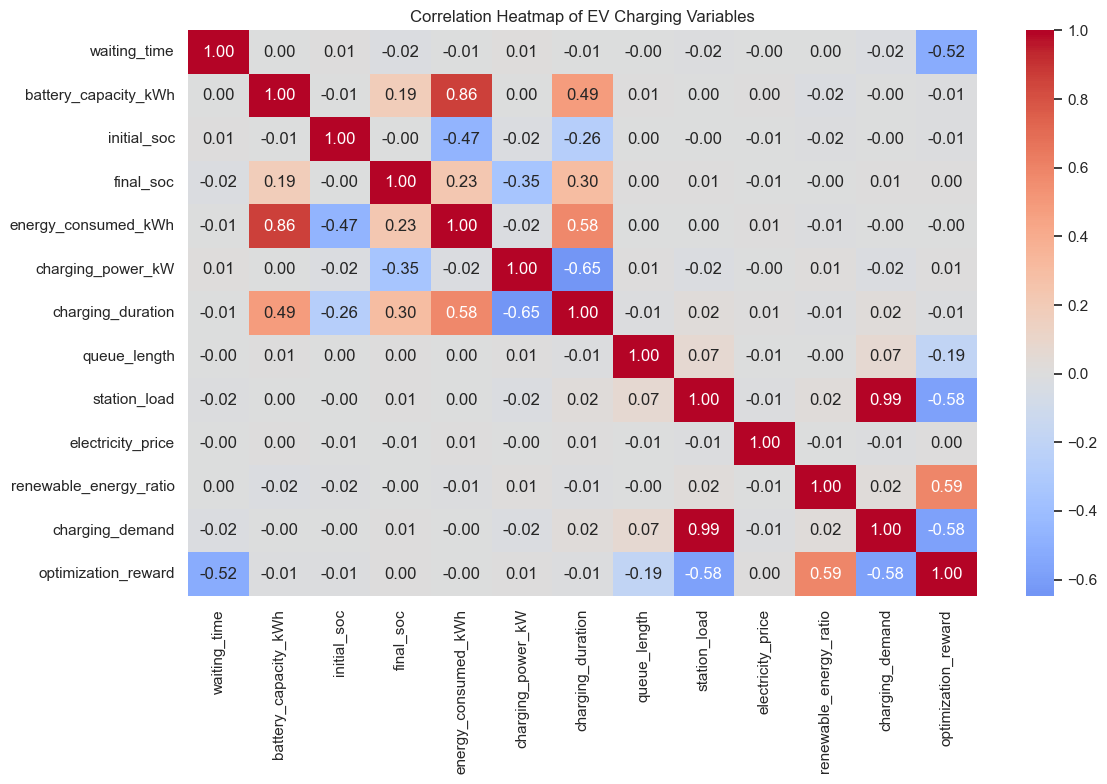

In [33]:
numeric_cols = [
    'waiting_time', 'battery_capacity_kWh', 'initial_soc', 'final_soc',
    'energy_consumed_kWh', 'charging_power_kW', 'charging_duration',
    'queue_length', 'station_load', 'electricity_price',
    'renewable_energy_ratio', 'charging_demand', 'optimization_reward'
]

numeric_cols = [col for col in numeric_cols if col in df_cleaned.columns]
corr_matrix = df_cleaned[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', center=0)
plt.title('Correlation Heatmap of EV Charging Variables')
plt.tight_layout()
plt.show()


**Interpretation:** The correlation heatmap shows the strength and direction of relationships between numerical variables. Strong positive or negative values indicate variables that may be important for EV charging behavior, such as the relationship between charging power and charging duration, or station load and charging demand.


## Advanced Visual: Station Load vs Waiting Time

This scatterplot shows whether higher station load is associated with longer waiting time, while separating the points by traffic density.


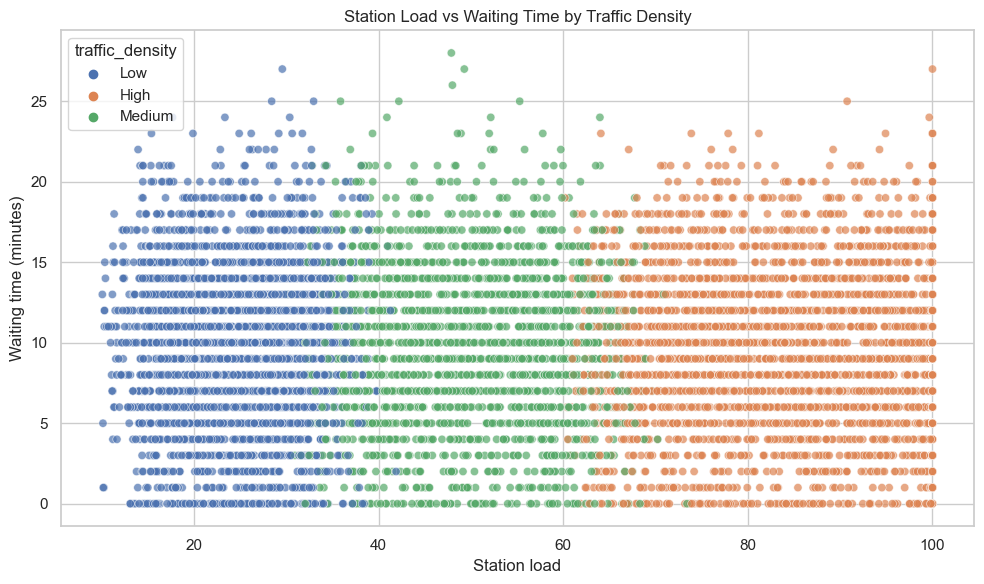

In [34]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_cleaned,
    x='station_load',
    y='waiting_time',
    hue='traffic_density',
    alpha=0.7
)
plt.title('Station Load vs Waiting Time by Traffic Density')
plt.xlabel('Station load')
plt.ylabel('Waiting time (minutes)')
plt.tight_layout()
plt.show()


**Interpretation:** This scatterplot helps identify whether operational congestion at charging stations is linked to waiting time. If points with higher station load also show longer waiting time, it suggests that station capacity and traffic density may contribute to user delay.


## Assumption Tests Before ANOVA

Before ANOVA, Shapiro-Wilk is used to check normality and Levene's test is used to check equality of variance. For large datasets, small p-values are common, so these results should be interpreted together with graphs and group summaries.


In [35]:
# Shapiro-Wilk normality test
# H0: The sample is normally distributed.
# H1: The sample is not normally distributed.

for col in ['charging_power_kW', 'charging_duration', 'waiting_time']:
    sample = df_cleaned[col].dropna().sample(n=min(500, df_cleaned[col].dropna().shape[0]), random_state=42)
    stat, p_value = shapiro(sample)
    print(f'{col}')
    print('Shapiro-Wilk statistic:', round(stat, 4))
    print('P-value:', round(p_value, 5))
    if p_value < 0.05:
        print('Result: Not normally distributed at 5% significance level.\n')
    else:
        print('Result: Approximately normally distributed at 5% significance level.\n')


charging_power_kW
Shapiro-Wilk statistic: 0.7483
P-value: 0.0
Result: Not normally distributed at 5% significance level.

charging_duration
Shapiro-Wilk statistic: 0.8668
P-value: 0.0
Result: Not normally distributed at 5% significance level.

waiting_time
Shapiro-Wilk statistic: 0.9889
P-value: 0.00076
Result: Not normally distributed at 5% significance level.



In [36]:
# Levene's test for equal variance across traffic density groups
# H0: Variances are equal across groups.
# H1: At least one group has different variance.

low = df_cleaned[df_cleaned['traffic_density'] == 'Low']['waiting_time']
medium = df_cleaned[df_cleaned['traffic_density'] == 'Medium']['waiting_time']
high = df_cleaned[df_cleaned['traffic_density'] == 'High']['waiting_time']

levene_stat, levene_p = levene(low, medium, high)
print('Levene statistic:', round(levene_stat, 4))
print('P-value:', round(levene_p, 5))

if levene_p < 0.05:
    print('Result: Variances are significantly different.')
else:
    print('Result: No significant variance difference detected.')


Levene statistic: 0.2391
P-value: 0.78733
Result: No significant variance difference detected.


## Pearson Correlation Test

Research question: Is charging power significantly related to charging duration?

- **H0:** There is no significant linear relationship between charging power and charging duration.
- **H1:** There is a significant linear relationship between charging power and charging duration.


In [37]:
corr, p = pearsonr(
    df_cleaned['charging_power_kW'],
    df_cleaned['charging_duration']
)

print('Correlation:', round(corr, 4))
print('P-value:', round(p, 5))

if p < 0.05:
    print('Significant relationship exists between charging power and charging duration.')
else:
    print('No significant relationship exists between charging power and charging duration.')


Correlation: -0.6471
P-value: 0.0
Significant relationship exists between charging power and charging duration.


**Interpretation:** If the correlation is negative and significant, higher charging power is associated with shorter charging duration. This is important for intelligent transportation systems because faster chargers can reduce station occupancy time and improve charging flow.


## ANOVA Test

Research question: Does waiting time differ across low, medium, and high traffic density?

- **H0:** Mean waiting time is the same across all traffic density groups.
- **H1:** At least one traffic density group has a different mean waiting time.


In [38]:
# Group summary before ANOVA
df_cleaned.groupby('traffic_density')['waiting_time'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).round(3)


,count,mean,median,std,min,max
traffic_density,,,,,,
High,3132,9.431,9.000,4.886,0,27
Low,3134,9.581,10.000,4.868,0,27
Medium,2088,9.588,9.000,4.946,0,28


In [39]:
low = df_cleaned[df_cleaned['traffic_density'] == 'Low']['waiting_time']
medium = df_cleaned[df_cleaned['traffic_density'] == 'Medium']['waiting_time']
high = df_cleaned[df_cleaned['traffic_density'] == 'High']['waiting_time']

f_stat, p_value = f_oneway(low, medium, high)

print('F-statistic:', round(f_stat, 4))
print('P-value:', round(p_value, 5))

if p_value < 0.05:
    print('Reject H0: Waiting time differs significantly across traffic density groups.')
else:
    print('Fail to reject H0: No significant difference in waiting time across traffic density groups.')


F-statistic: 0.9512
P-value: 0.38632
Fail to reject H0: No significant difference in waiting time across traffic density groups.


**Interpretation:** If the ANOVA result is significant, traffic density is statistically associated with waiting time. This supports the ITS idea that road traffic conditions and charging station delay can be connected.


# Final Conclusion

1. Peak and off-peak patterns help show whether EV charging demand follows daily transportation movement.
2. Traffic density and waiting-time analysis shows whether congestion conditions affect EV charging station delay.
3. Station utilization patterns identify which stations may require better charger allocation or queue management.
4. The correlation heatmap and Pearson test provide statistical evidence for relationships between charging variables.
5. ANOVA provides formal hypothesis testing to determine whether waiting time differs across traffic density groups.
6. Overall, the EV charging dataset demonstrates clear relevance to Intelligent Transportation Systems because it links mobility behavior, charging infrastructure, traffic conditions, and operational efficiency.
